In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import model_selection
from sklearn.model_selection import train_test_split

In [42]:
dataset_path = 'perfume_type_classification_dataset.csv'
df = pd.read_csv(dataset_path)
df

,longevity_hours,sillage_score,top_note_count,price_usd,concentration_percent,fragrance_family,brand_tier,gender_target,contains_alcohol,limited_edition,perfume_category
0,5.96,5.80,5,103.71,17.04,Floral,Designer,Men,0.0,0,Eau de Parfum
1,8.85,7.70,4,122.93,15.28,Oriental,Luxury,Men,1.0,0,Eau de Toilette
2,0.54,2.67,3,105.21,12.69,Fresh,Designer,Men,0.0,0,Eau de Toilette
3,9.83,8.06,7,165.64,20.95,Floral,Luxury,Women,1.0,0,Eau de Parfum
4,11.03,9.72,5,279.00,25.00,Oriental,Luxury,Women,1.0,0,Perfume Extract
...,...,...,...,...,...,...,...,...,...,...,...
69995,8.29,7.82,6,67.13,7.61,Citrus,Luxury,Men,1.0,0,Eau de Toilette
69996,5.92,3.82,6,71.81,11.16,Oriental,Niche,Women,1.0,0,Eau de Toilette
69997,7.55,5.13,5,23.56,18.84,Citrus,Drugstore,Women,1.0,0,Eau de Parfum
69998,3.09,7.37,5,71.07,21.56,Fresh,Drugstore,Men,1.0,0,Eau de Parfum


|name   | description|
|-------|------------|
|longevity_hours	|	How long the scent lasts|
|sillage_score	|	Scent trail/projection strength (1–10)|
|top_note_count	|	Number of top notes (fewer in stronger concentrations)|
|price_usd	|	Retail price|
|concentration_percent	|	Fragrance oil concentration (%)|
|fragrance_family	|	Floral / Woody / Oriental / Fresh / Citrus|
|brand_tier	|	Luxury / Designer / Niche / Drugstore|
|gender_target	|	Men / Women / Unisex|
|contains_alcohol	|	0/1 yes or no|
|limited_edition	|	0/1 yes or no|
|perfume_category	|	Eau de Cologne / Eau de Toilette / Eau de Parfum / Perfume Extract|

As we can see our dataset has 70k rows and 10 features as well as one target feature - perfume_category

In [3]:
df.describe()

,longevity_hours,sillage_score,top_note_count,price_usd,concentration_percent,contains_alcohol,limited_edition
count,70000.000000,70000.000000,70000.000000,69272.000000,70000.000000,68251.000000,70000.000000
mean,5.702075,5.572562,5.366800,98.586296,13.467856,0.853350,0.122386
std,3.180509,2.452350,2.408247,69.429082,7.500726,0.353759,0.327733
min,0.500000,1.000000,1.000000,10.000000,1.500000,0.000000,0.000000
25%,3.360000,3.770000,4.000000,42.740000,7.820000,1.000000,0.000000
50%,5.530000,5.580000,5.000000,89.700000,12.910000,1.000000,0.000000
75%,7.810000,7.390000,7.000000,141.902500,18.410000,1.000000,0.000000
max,16.000000,10.000000,10.000000,428.130000,35.000000,1.000000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   longevity_hours        70000 non-null  float64
 1   sillage_score          70000 non-null  float64
 2   top_note_count         70000 non-null  int64  
 3   price_usd              69272 non-null  float64
 4   concentration_percent  70000 non-null  float64
 5   fragrance_family       70000 non-null  object 
 6   brand_tier             66497 non-null  object 
 7   gender_target          70000 non-null  object 
 8   contains_alcohol       68251 non-null  float64
 9   limited_edition        70000 non-null  int64  
 10  perfume_category       70000 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 5.9+ MB


#### Cleaning and exploring features

In [5]:
df.duplicated().sum()

np.int64(15000)

In [6]:
df = df.drop_duplicates()
df.isnull().sum()

longevity_hours             0
sillage_score               0
top_note_count              0
price_usd                 550
concentration_percent       0
fragrance_family            0
brand_tier               2750
gender_target               0
contains_alcohol         1375
limited_edition             0
perfume_category            0
dtype: int64

In [7]:
X = df.drop(columns='perfume_category')
y = df['perfume_category']

<Axes: xlabel='perfume_category', ylabel='count'>

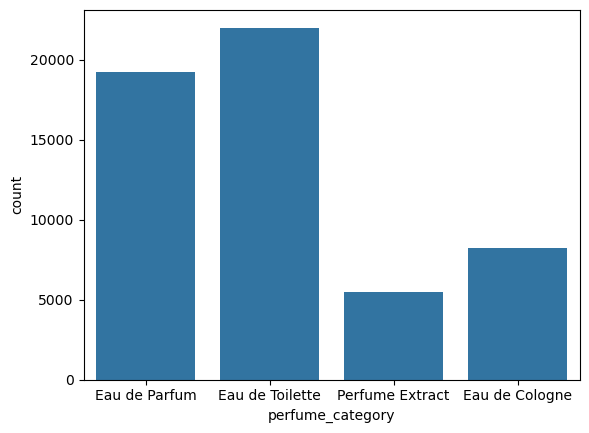

In [ ]:
sns.countplot(data=df, x='perfume_category')

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [ ]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [12]:
cat_cols = [name for name in X.columns if X[name].dtype == object]
num_cols = [name for name in X.columns if X[name].dtype == float or df[name].dtype == int]

In [13]:
df.loc[:, num_cols] = df[num_cols].fillna(df[num_cols].median())
df.loc[:, cat_cols] = df[cat_cols].fillna('Unknown')

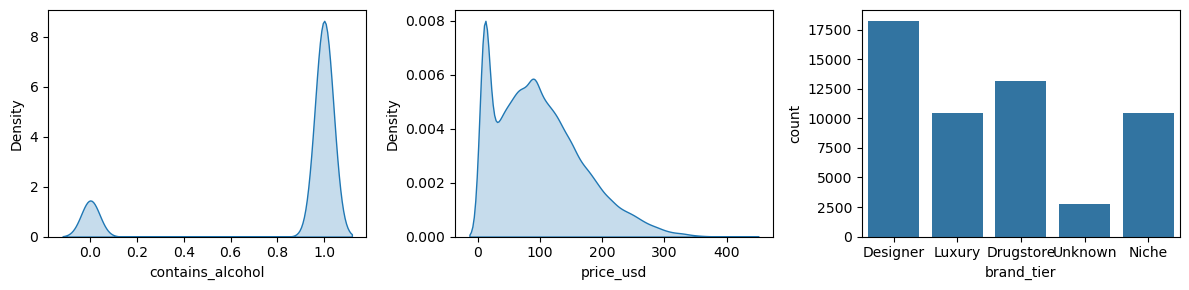

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
sns.kdeplot(data=df, x=df['contains_alcohol'], ax=axes[0], fill = True)
sns.kdeplot(data=df, x=df['price_usd'], ax=axes[1], fill = True)
sns.countplot(data=df, x=df['brand_tier'], ax=axes[2])
plt.tight_layout()
plt.show()

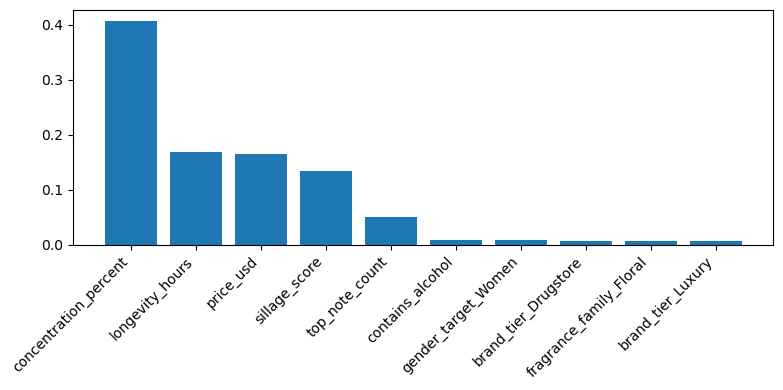

In [49]:
X_temp = pd.get_dummies(X, columns=cat_cols, drop_first=True)
rf_for_features = RandomForestClassifier(random_state=42)
rf_for_features.fit(X_temp, y)
importances = rf_for_features.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), X_temp.columns[indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

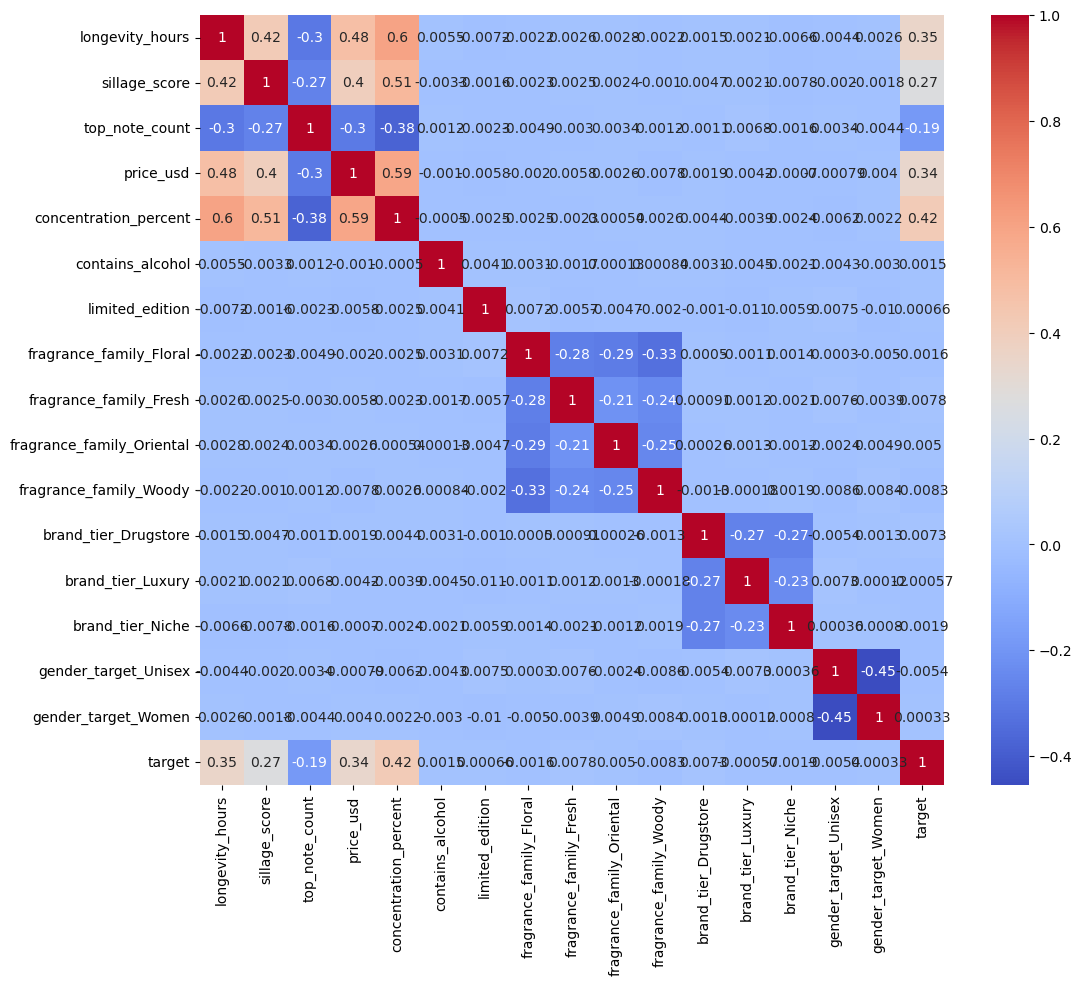

In [45]:
plt.figure(figsize=(12, 10))
corr_df = X_temp
corr_df['target']=y
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.show()

#### Lets get to plottin'

<Axes: ylabel='concentration_percent'>

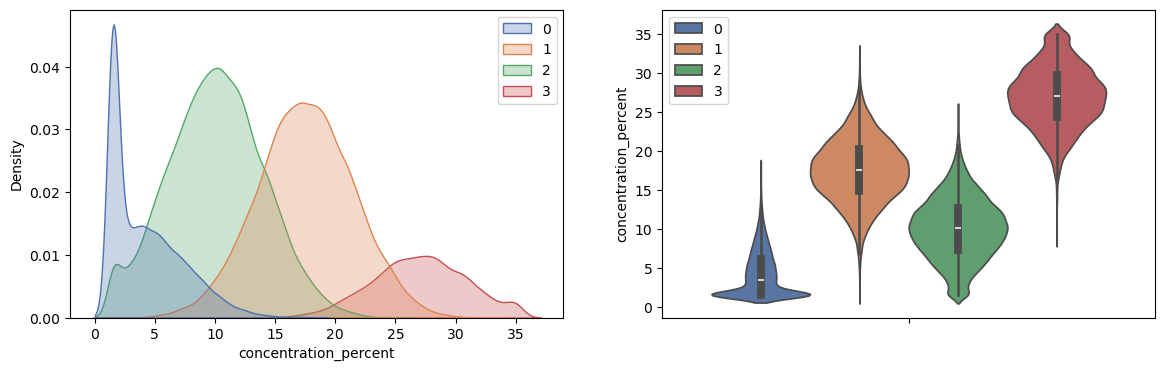

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.kdeplot(x=X_temp['concentration_percent'], hue=y, fill=True, alpha = 0.3, palette='deep', ax=axes[0])
sns.violinplot(y=X_temp['concentration_percent'], hue=y, palette='deep', ax=axes[1])

<Axes: ylabel='longevity_hours'>

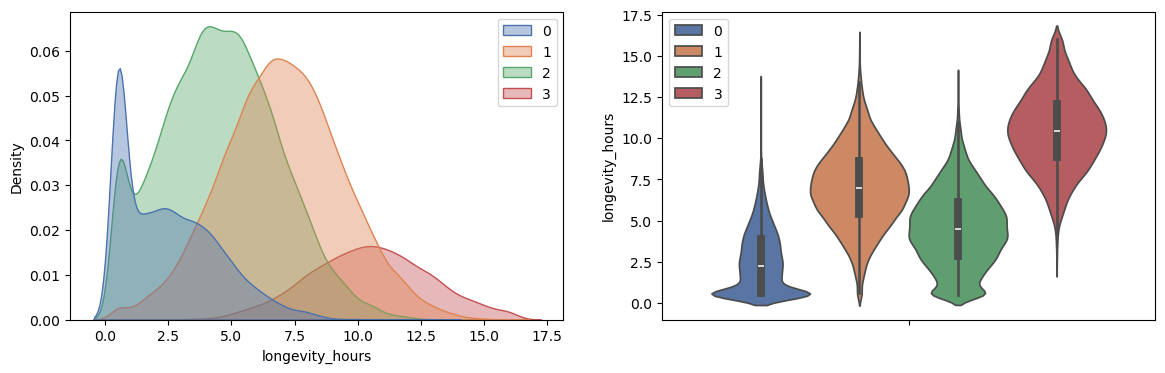

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.kdeplot(x=X_temp['longevity_hours'], hue=y, fill=True, alpha=0.4, palette='deep', ax=axes[0])
sns.violinplot(y=X_temp['longevity_hours'], hue=y, palette='deep', ax=axes[1])

<Axes: xlabel='price_usd', ylabel='Count'>

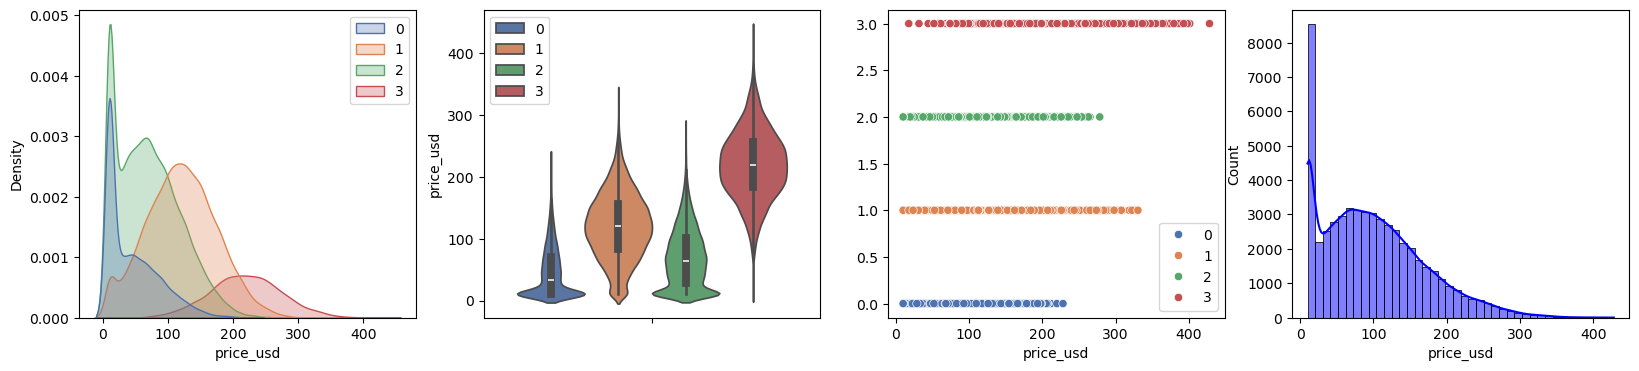

In [52]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
sns.kdeplot(x=X_temp['price_usd'], hue=y, fill=True, alpha = 0.3, palette='deep', ax=axes[0])
sns.violinplot(y=X_temp['price_usd'], hue=y, palette='deep', ax=axes[1])
sns.scatterplot(x=X_temp['price_usd'], y=y, hue=y, palette='deep', ax=axes[2])
sns.histplot(x=X_temp['price_usd'], kde=True, ax=axes[3], bins=40, color='blue')

<Axes: ylabel='sillage_score'>

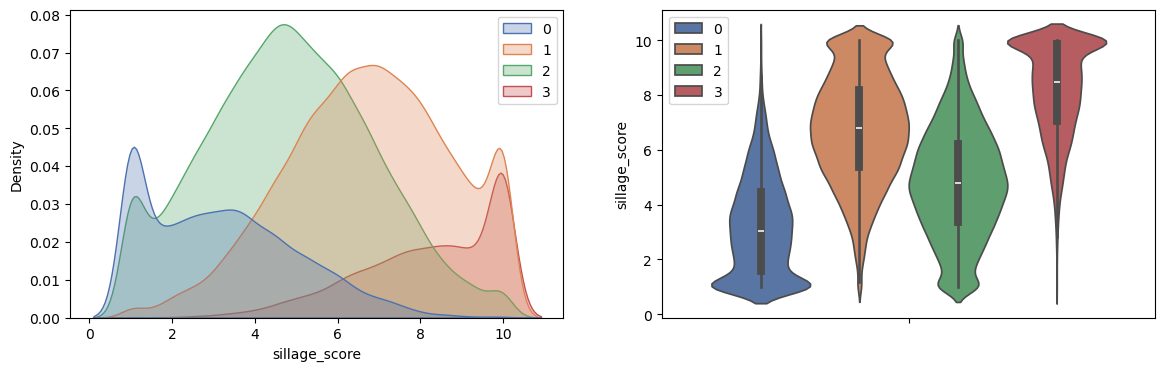

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.kdeplot(x=X_temp['sillage_score'], hue=y, fill=True, alpha = 0.3, palette='deep', ax=axes[0])
sns.violinplot(y=X_temp['sillage_score'], hue=y, palette='deep', ax=axes[1])


#### Making data more balanced by adding our SMOTE realisation (why tho...)

In [26]:
from imblearn.pipeline import Pipeline
from imblearn.base import BaseSampler

In [35]:
from sklearn.base import TransformerMixin

class CustomSMOTE(BaseSampler, TransformerMixin):
    """
    Самописный класс SMOTE, полностью совместимый с Pipeline библиотеки imblearn,
    GridSearchCV и современными стандартами валидации параметров scikit-learn.
    """
    
    # Обязательный атрибут для scikit-learn (исправляет AttributeError: _parameter_constraints)
    _parameter_constraints = {}

    def __init__(self, target_class, oversampling_rate=1.0, k_neighbors=5, cat_indices=None):
        # Явно вызываем конструктор BaseSampler для настройки сэмплера
        BaseSampler.__init__(self)
        self.target_class = target_class
        self.oversampling_rate = oversampling_rate
        self.k_neighbors = k_neighbors
        self.cat_indices = cat_indices if cat_indices is not None else []
        self._sampling_type = 'over-sampling'

    def _fit_resample(self, X, y):
        X_arr = np.asarray(X, dtype=float)
        y_arr = np.asarray(y)

        # Выделяем объекты миноритарного (целевого) класса
        minority_samples = X_arr[y_arr == self.target_class]
        n_samples, n_features = minority_samples.shape

        if n_samples <= self.k_neighbors:
            raise ValueError(f"Количество объектов класса {self.target_class} ({n_samples}) слишком мало для k_neighbors={self.k_neighbors}")

        n_synthetic = int(n_samples * self.oversampling_rate)
        synthetic_samples = np.empty((n_synthetic, n_features))

        for i in range(n_synthetic):
            base_idx = np.random.randint(0, n_samples)
            base_sample = minority_samples[base_idx]
            
            distances = np.linalg.norm(minority_samples - base_sample, axis=1)
            
            nn_indices = np.argsort(distances)[1 : self.k_neighbors + 1]
            chosen_neighbor_idx = np.random.choice(nn_indices)
            neighbor_sample = minority_samples[chosen_neighbor_idx]

            gap = np.random.rand()
            synthetic_specimen = base_sample + gap * (neighbor_sample - base_sample)
            
            # Округляем One-Hot-Encoded признаки до жестких 0 или 1
            for idx in self.cat_indices:
                synthetic_specimen[idx] = np.round(synthetic_specimen[idx])
                
            synthetic_samples[i] = synthetic_specimen

        X_balanced = np.vstack((X_arr, synthetic_samples))
        y_synthetic = np.full(n_synthetic, self.target_class)
        y_balanced = np.concatenate((y_arr, y_synthetic))

        return X_balanced, y_balanced

    # Метод-заглушка для прохождения внутренней валидации шагов в GridSearchCV
    def transform(self, X):
        return X


In [23]:
df['perfume_category'].value_counts()

perfume_category
Eau de Toilette    22014
Eau de Parfum      19254
Eau de Cologne      8258
Perfume Extract     5474
Name: count, dtype: int64

In [24]:
print(list(target_encoder.classes_).index('Eau de Cologne'))
print(list(target_encoder.classes_).index('Perfume Extract'))


0
3


In [29]:
categorical_pipe = Pipeline(steps=[
    ('cat_imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

numerical_pipe = Pipeline(steps=[
    ('num_imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('cat_tf', categorical_pipe, cat_cols),
    ('num_tf', numerical_pipe, num_cols)
])
preprocessor.fit(X_train)
num_cat_features_after_ohe = preprocessor.named_transformers_['cat_tf']['one_hot_encoder'].get_feature_names_out().shape[0]
cat_indices = list(range(num_cat_features_after_ohe))

In [36]:
# Базовый словарь моделей и сеток параметров для GridSearchCV


model_tuning_configs = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'classifier__n_neighbors': [3, 5, 7],
            'classifier__weights': ['uniform', 'distance']
        }
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'classifier__C':[0.1, 1, 10],
            'classifier__kernel': ['rbf']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 500, 800],
            'classifier__max_depth': [10, 20, None]
        }
    }
}

best_models = {}

for model_name, config in model_tuning_configs.items():
    print(f"Запуск GridSearchCV для {model_name}...")
    
    # Строим итоговый пайплайн с последовательным применением кастомного SMOTE для двух редких классов
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        # Класс 0 (Eau de Cologne) увеличиваем примерно в 2 раза
        ('smote_class_0', CustomSMOTE(target_class=0, oversampling_rate=1.0, k_neighbors=3, cat_indices=cat_indices)),
        # Класс 3 (Perfume Extract) увеличиваем примерно в 4 раза
        ('smote_class_3', CustomSMOTE(target_class=3, oversampling_rate=3.0, k_neighbors=3, cat_indices=cat_indices)),
        ('classifier', config['model'])
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=3,                 # 3-фолдовая кросс-валидация
        scoring='f1_macro',   # макро-усреднение f1 для несбалансированных задач
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    print(f"Лучшие параметры для {model_name}: {grid_search.best_params_}")
    print(f"Лучший F1-Macro на кросс-валидации: {grid_search.best_score_:.4f}\n")
    
    # Сохраняем лучшую обученную модель
    best_models[model_name] = grid_search.best_estimator_


Запуск GridSearchCV для KNN...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Лучшие параметры для KNN: {'classifier__n_neighbors': 7, 'classifier__weights': 'distance'}
Лучший F1-Macro на кросс-валидации: 0.8058

Запуск GridSearchCV для SVM...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Лучшие параметры для SVM: {'classifier__C': 1, 'classifier__kernel': 'rbf'}
Лучший F1-Macro на кросс-валидации: 0.8496

Запуск GridSearchCV для Random Forest...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Лучшие параметры для Random Forest: {'classifier__max_depth': None, 'classifier__n_estimators': 800}
Лучший F1-Macro на кросс-валидации: 0.8467



In [40]:
print("Исходный баланс в трейне:")
print(np.bincount(y_train))

# Инициализируем твои шаги генерации вручную для проверки
smote_0 = CustomSMOTE(target_class=0, oversampling_rate=1.0, k_neighbors=3, cat_indices=cat_indices)
smote_3 = CustomSMOTE(target_class=3, oversampling_rate=3.0, k_neighbors=3, cat_indices=cat_indices)

# Прогоняем тренировочный набор через препроцессор (так как SMOTE работает с числами)
X_train_encoded = preprocessor.transform(X_train)

# Применяем генерацию
X_res, y_res = smote_0.fit_resample(X_train_encoded, y_train)
X_res, y_res = smote_3.fit_resample(X_res, y_res)

print("\nБаланс классов в трейне ПОСЛЕ генерации твоим скриптом:")
print(np.bincount(y_res))

Исходный баланс в тренировочном трейне:
[ 6607 15403 17611  4379]

Баланс классов в трейне ПОСЛЕ генерации твоим скриптом:
[13214 15403 17611 17516]



================ Оценка качества модели: KNN ================
                 precision    recall  f1-score   support

 Eau de Cologne       0.77      0.65      0.70      1651
  Eau de Parfum       0.83      0.85      0.84      3851
Eau de Toilette       0.76      0.81      0.79      4403
Perfume Extract       0.94      0.85      0.89      1095

       accuracy                           0.80     11000
      macro avg       0.82      0.79      0.80     11000
   weighted avg       0.80      0.80      0.80     11000

ROC-AUC Score (One-vs-Rest, Macro): 0.9403


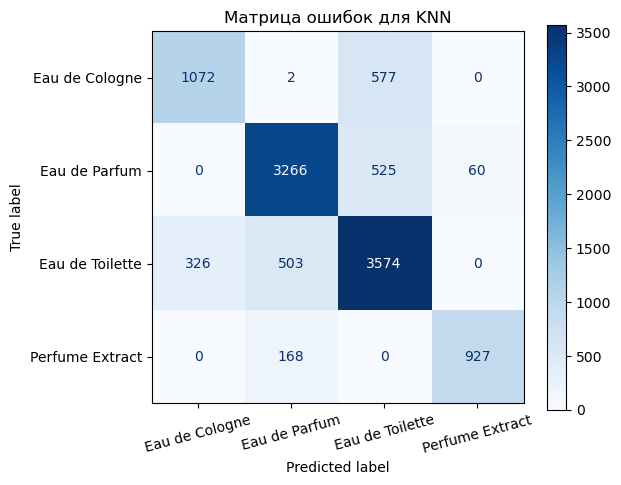


================ Оценка качества модели: SVM ================
                 precision    recall  f1-score   support

 Eau de Cologne       0.82      0.73      0.77      1651
  Eau de Parfum       0.87      0.87      0.87      3851
Eau de Toilette       0.81      0.85      0.83      4403
Perfume Extract       0.94      0.90      0.92      1095

       accuracy                           0.84     11000
      macro avg       0.86      0.84      0.85     11000
   weighted avg       0.84      0.84      0.84     11000

ROC-AUC Score (One-vs-Rest, Macro): 0.9656


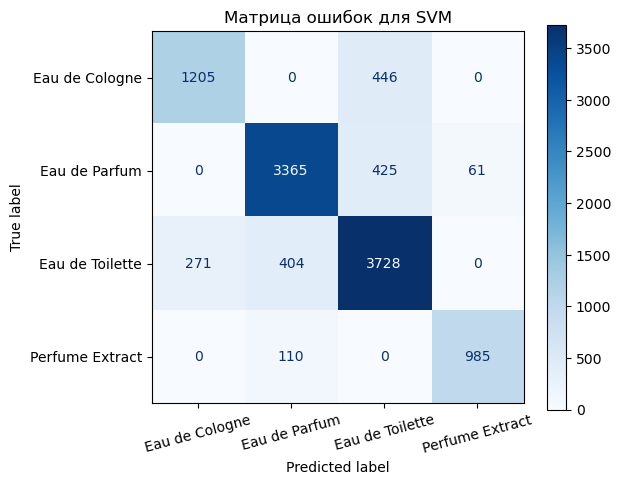


================ Оценка качества модели: Random Forest ================
                 precision    recall  f1-score   support

 Eau de Cologne       0.82      0.72      0.76      1651
  Eau de Parfum       0.86      0.88      0.87      3851
Eau de Toilette       0.81      0.84      0.82      4403
Perfume Extract       0.95      0.88      0.92      1095

       accuracy                           0.84     11000
      macro avg       0.86      0.83      0.84     11000
   weighted avg       0.84      0.84      0.84     11000

ROC-AUC Score (One-vs-Rest, Macro): 0.9636


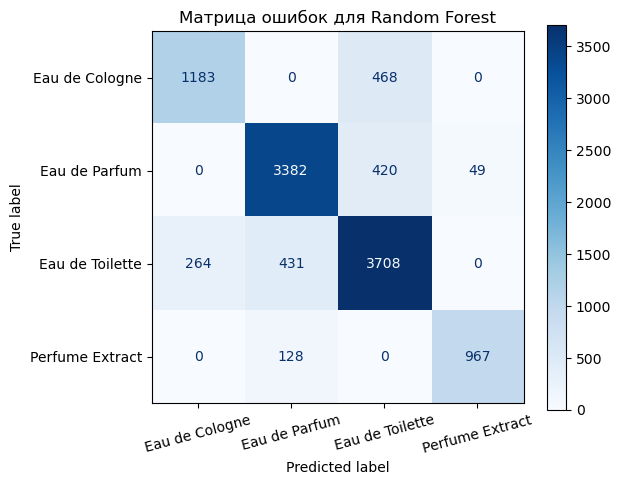

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, roc_auc_score


for model_name, pipeline in best_models.items():
    print(f"\n================ Оценка качества модели: {model_name} ================")
    
    # Предсказание классов и вероятностей (для ROC-AUC)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)
    
    # а. Вывод текстового отчета по основным метрикам
    print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))
    
    # Расчет многоклассового ROC-AUC (стратегия One-vs-Rest)
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    print(f"ROC-AUC Score (One-vs-Rest, Macro): {roc_auc:.4f}")
    
    # b. Визуализация предсказанных значений (Матрица ошибок)
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    ax.set_title(f'Матрица ошибок для {model_name}')
    plt.xticks(rotation=15)
    plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_9460\3142269541.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[all_feature_names[i] for i in indices], palette='viridis')


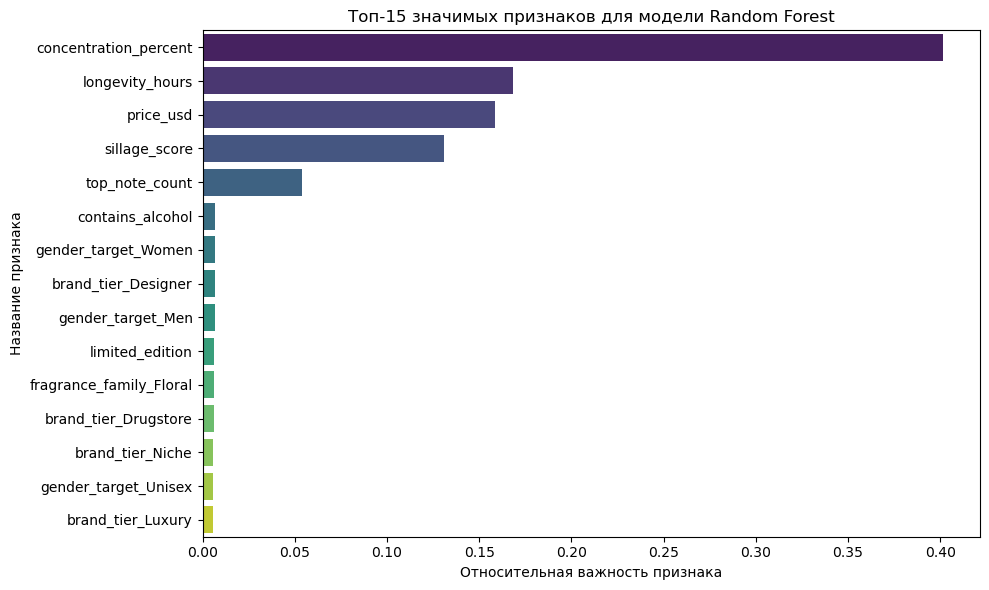

In [39]:
# Извлекаем лучшую модель Случайного Леса из сохраненного словаря
rf_pipeline = best_models['Random Forest']

# Достаем названия колонок после кодирования OneHotEncoder
cat_feature_names = list(rf_pipeline.named_steps['preprocessor'].named_transformers_['cat_tf']['one_hot_encoder'].get_feature_names_out(cat_cols))
all_feature_names = cat_feature_names + num_cols

# Извлекаем важность признаков
importances = rf_pipeline.named_steps['classifier'].feature_importances_

# Сортируем топ-15 значимых признаков
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[all_feature_names[i] for i in indices], palette='viridis')
plt.title('Топ-15 значимых признаков для модели Random Forest')
plt.xlabel('Относительная важность признака')
plt.ylabel('Название признака')
plt.tight_layout()
plt.show()
